# Label distribution diagnostic — CellCast v0

Reads `data/sciplex/processed/cellcast_v0.parquet`, flattens all 2,256 × 7,153 LFC
values, and reports distribution shape, dead genes, and per-cell-line differences.
The output is meant to inform M4 reporting — what fraction of the target is signal
vs. floor, whether the task is dominated by a few cell lines, etc.

In [1]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

PROC = Path(os.path.expanduser("~/cellcast/data/sciplex/processed"))
df = pd.read_parquet(PROC / "cellcast_v0.parquet")
print(f"rows: {len(df):,}  cell lines: {sorted(df['cell_line'].unique())}")
lfc = np.stack([np.asarray(v) for v in df['label_lfc_vector']]).astype(np.float32)
print(f"LFC matrix shape: {lfc.shape}  dtype: {lfc.dtype}")

with open(PROC / "hvg_genes.txt") as f:
    hvg = [g.strip() for g in f if g.strip()]
print(f"HVG count: {len(hvg)}")
assert lfc.shape[1] == len(hvg)

rows: 2,256  cell lines: ['A549', 'K562', 'MCF7']
LFC matrix shape: (2256, 7153)  dtype: float32
HVG count: 7153


## 1. Global distribution: histogram + percentiles + |LFC| brackets

In [2]:
flat = lfc.ravel()
qs = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
pcts = {q: float(np.quantile(flat, q)) for q in qs}
print("Percentiles of LFC (flattened, N={:,}):".format(len(flat)))
for q, v in pcts.items():
    print(f"  q={q:>5}: {v:+.4f}")
print()
abs_flat = np.abs(flat)
brackets = {
    "|LFC| < 0.1":           float((abs_flat < 0.1).mean()),
    "0.1 <= |LFC| < 0.5":    float(((abs_flat >= 0.1) & (abs_flat < 0.5)).mean()),
    "0.5 <= |LFC| < 1.0":    float(((abs_flat >= 0.5) & (abs_flat < 1.0)).mean()),
    "|LFC| >= 1.0":          float((abs_flat >= 1.0).mean()),
}
print("Fraction by |LFC| bracket:")
for k, v in brackets.items():
    print(f"  {k:<25}: {v*100:>6.2f}%")

Percentiles of LFC (flattened, N=16,137,168):
  q= 0.01: -0.2398
  q= 0.05: -0.1171
  q= 0.25: -0.0280
  q=  0.5: -0.0034
  q= 0.75: +0.0226
  q= 0.95: +0.1131
  q= 0.99: +0.2321

Fraction by |LFC| bracket:
  |LFC| < 0.1              :  87.27%
  0.1 <= |LFC| < 0.5       :  12.41%
  0.5 <= |LFC| < 1.0       :   0.28%
  |LFC| >= 1.0             :   0.04%


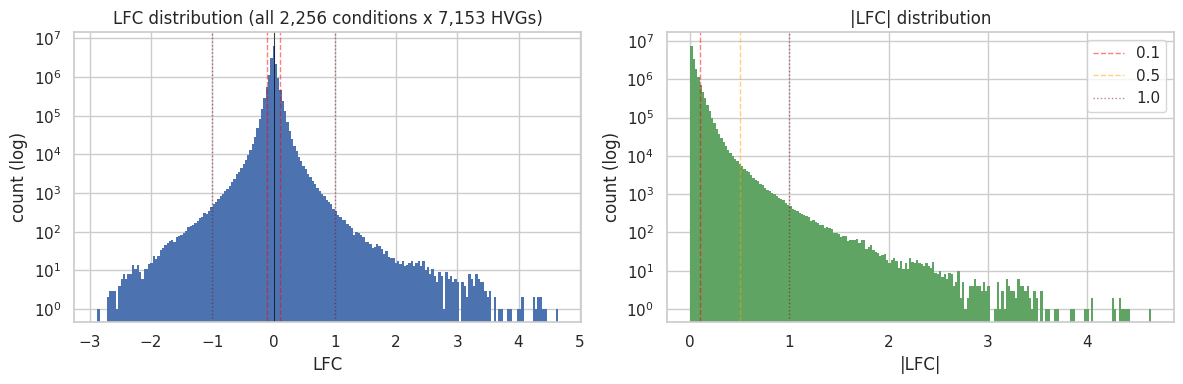

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.hist(flat, bins=200, color="#4c72b0", edgecolor="none")
ax.set_yscale("log")
ax.set_xlabel("LFC")
ax.set_ylabel("count (log)")
ax.set_title("LFC distribution (all 2,256 conditions x 7,153 HVGs)")
ax.axvline(0, color="black", linewidth=0.5)
ax.axvline(-0.1, color="red", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(+0.1, color="red", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(-1.0, color="darkred", linestyle=":", linewidth=1, alpha=0.5)
ax.axvline(+1.0, color="darkred", linestyle=":", linewidth=1, alpha=0.5)

ax = axes[1]
ax.hist(abs_flat, bins=200, color="#5fa463", edgecolor="none")
ax.set_yscale("log")
ax.set_xlabel("|LFC|")
ax.set_ylabel("count (log)")
ax.set_title("|LFC| distribution")
ax.axvline(0.1, color="red", linestyle="--", linewidth=1, alpha=0.5, label="0.1")
ax.axvline(0.5, color="orange", linestyle="--", linewidth=1, alpha=0.5, label="0.5")
ax.axvline(1.0, color="darkred", linestyle=":", linewidth=1, alpha=0.5, label="1.0")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Dead genes — never reach |LFC| > 0.1 across any condition

In [4]:
max_abs_per_gene = np.abs(lfc).max(axis=0)  # shape (7153,)
dead_mask = max_abs_per_gene < 0.1
n_dead = int(dead_mask.sum())
print(f"dead genes (|LFC| < 0.1 across all 2,256 conditions): {n_dead} / {len(hvg)} ({n_dead/len(hvg)*100:.1f}%)")
dead_genes = np.array(hvg)[dead_mask]
print()
print(f"First 20 dead gene symbols: {list(dead_genes[:20])}")

dead genes (|LFC| < 0.1 across all 2,256 conditions): 143 / 7153 (2.0%)

First 20 dead gene symbols: ['ABHD11-AS1', 'AC004803.1', 'AC006974.1', 'AC008115.3', 'AC010331.1', 'AC015795.1', 'AC015813.5', 'AC016590.3', 'AC017037.2', 'AC018552.4', 'AC020915.6', 'AC022211.2', 'AC023043.4', 'AC023158.2', 'AC026362.1', 'AC027575.4', 'AC037198.1', 'AC068134.3', 'AC069549.1', 'AC084128.1']


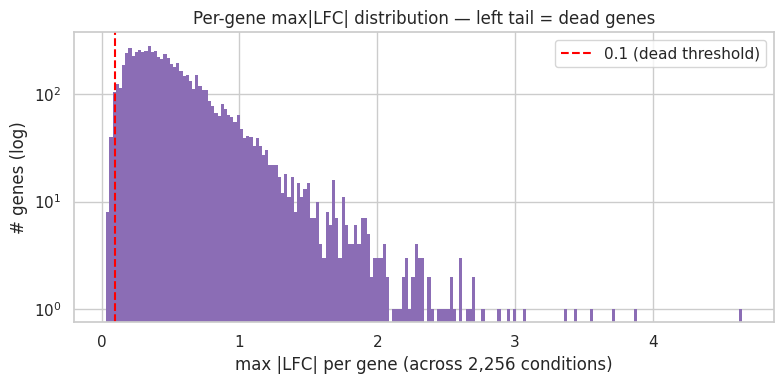

In [5]:
# Distribution of max|LFC| per gene
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_abs_per_gene, bins=200, color="#8b6db5", edgecolor="none")
ax.set_yscale("log")
ax.set_xlabel("max |LFC| per gene (across 2,256 conditions)")
ax.set_ylabel("# genes (log)")
ax.set_title("Per-gene max|LFC| distribution — left tail = dead genes")
ax.axvline(0.1, color="red", linestyle="--", label="0.1 (dead threshold)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Per-cell-line comparison

In [6]:
rows = []
for cl in sorted(df['cell_line'].unique()):
    sub = lfc[(df['cell_line']==cl).to_numpy()]
    flat_cl = sub.ravel()
    abs_cl = np.abs(flat_cl)
    rows.append({
        'cell_line': cl,
        'n_conditions': int((df['cell_line']==cl).sum()),
        'p01': np.quantile(flat_cl, 0.01),
        'p05': np.quantile(flat_cl, 0.05),
        'p25': np.quantile(flat_cl, 0.25),
        'p50': np.quantile(flat_cl, 0.50),
        'p75': np.quantile(flat_cl, 0.75),
        'p95': np.quantile(flat_cl, 0.95),
        'p99': np.quantile(flat_cl, 0.99),
        'frac_abs_gt_01': float((abs_cl > 0.1).mean()),
        'frac_abs_gt_05': float((abs_cl > 0.5).mean()),
        'frac_abs_gt_10': float((abs_cl > 1.0).mean()),
        'mean_abs': float(abs_cl.mean()),
    })
per_cl = pd.DataFrame(rows).set_index('cell_line')
print(per_cl.round(4).to_string())

           n_conditions     p01     p05     p25     p50     p75     p95     p99  frac_abs_gt_01  frac_abs_gt_05  frac_abs_gt_10  mean_abs
cell_line                                                                                                                                
A549                752 -0.2501 -0.1290 -0.0332 -0.0051  0.0272  0.1244  0.2392          0.1537          0.0037          0.0005    0.0537
K562                752 -0.2520 -0.1343 -0.0367 -0.0046  0.0317  0.1342  0.2552          0.1702          0.0029          0.0002    0.0570
MCF7                752 -0.1980 -0.0770 -0.0172 -0.0018  0.0140  0.0689  0.1751          0.0579          0.0029          0.0004    0.0329


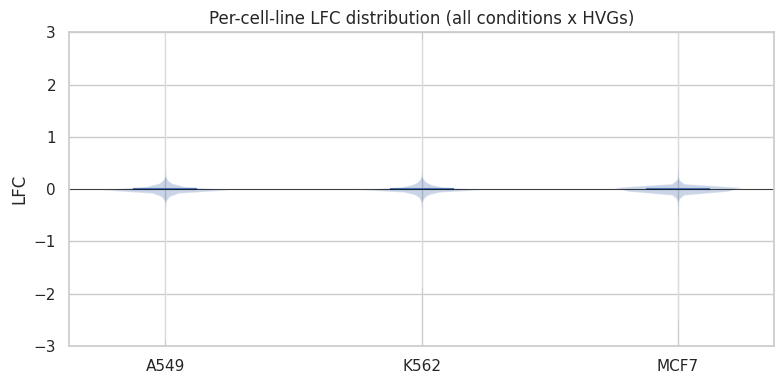

In [7]:
# Box+violin per cell line
fig, ax = plt.subplots(figsize=(8, 4))
data = [lfc[(df['cell_line']==cl).to_numpy()].ravel() for cl in sorted(df['cell_line'].unique())]
labels = sorted(df['cell_line'].unique())
parts = ax.violinplot(data, showmedians=True, showextrema=False)
ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels)
ax.set_ylabel("LFC")
ax.set_title("Per-cell-line LFC distribution (all conditions x HVGs)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

## 4. Summary numbers (compose into results/3c_label_diagnostics.md)

In [8]:
summary = {
    "n_conditions": int(lfc.shape[0]),
    "n_HVGs": int(lfc.shape[1]),
    "n_LFC_values": int(flat.size),
    "global_percentiles": {f"p{int(q*100):02d}": float(np.quantile(flat, q)) for q in [0.01,0.05,0.25,0.5,0.75,0.95,0.99]},
    "abs_brackets": brackets,
    "n_dead_genes_max_abs_lt_0.1": n_dead,
    "frac_dead_genes": n_dead / len(hvg),
    "per_cell_line": per_cl.to_dict(orient='index'),
}
print(json.dumps(summary, indent=2, default=lambda x: float(x) if hasattr(x,'item') else x))

{
  "n_conditions": 2256,
  "n_HVGs": 7153,
  "n_LFC_values": 16137168,
  "global_percentiles": {
    "p01": -0.23977502956986427,
    "p05": -0.1170854166150093,
    "p25": -0.02803099900484085,
    "p50": -0.0033710943534970284,
    "p75": 0.022621801123023033,
    "p95": 0.11314844936132418,
    "p99": 0.2320597097277643
  },
  "abs_brackets": {
    "|LFC| < 0.1": 0.8727136632648306,
    "0.1 <= |LFC| < 0.5": 0.1241017011163297,
    "0.5 <= |LFC| < 1.0": 0.002779360046322874,
    "|LFC| >= 1.0": 0.00040527557251681333
  },
  "n_dead_genes_max_abs_lt_0.1": 143,
  "frac_dead_genes": 0.019991611911086258,
  "per_cell_line": {
    "A549": {
      "n_conditions": 752,
      "p01": -0.25010526925325394,
      "p05": -0.1290169209241867,
      "p25": -0.03324347734451294,
      "p50": -0.0050523895770311356,
      "p75": 0.027172080241143703,
      "p95": 0.12437686137855053,
      "p99": 0.23920554965734483,
      "frac_abs_gt_01": 0.15373422399766798,
      "frac_abs_gt_05": 0.0037108741